# Aruba population trends, 2015-2023

## Average domiciliation and departures by country

Source files: Table-1.11-Domiciliation-by-country-of-birth-and-sex.xlsx\
<span style="padding-left: 5.7em;">Table-1.12-Departures-by-country-of-birth-and-sex.xlsx</span>

Source: CBS Aruba and the Population Registry Office

---
## 1. Setup

### Imports and paths

The following block of code creates a reproducible notebook environment by using **import sys** and configuring the project path.

In [1]:
# Importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Establish paths

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

from config.project_paths import (
    ROOT,
    DATA_PROCESSED,
    FIGURES
)

In [2]:
# Verify all paths to ensure stable environment

print("ROOT:", ROOT)
print("PROCESSED DATA:", DATA_PROCESSED)
print("FIGURES:", FIGURES)

ROOT: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba
PROCESSED DATA: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/data/processed
FIGURES: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/outputs/figures


In [3]:
# Load processed CSV data files

DOMICIL_PROCESSED = DATA_PROCESSED / "domiciliation_table.csv"
DEP_PROCESSED = DATA_PROCESSED / "departures_table.csv"

In [4]:
# Stop early if the source file is missing

if not DOMICIL_PROCESSED.exists():
    raise FileNotFoundError

if not DEP_PROCESSED.exists():
    raise FileNotFoundError

## 2. Load and inspect source data

In [5]:
# Assign varibles to both files

dom_df = pd.read_csv(DOMICIL_PROCESSED)
dep_df = pd.read_csv(DEP_PROCESSED)

## 3. Standardize column names and create 'Total' labels

In [6]:
# Renaming of column names for easier matching during analysis

dom_df = dom_df.rename(columns={"Country":"country",
                          "value":"domiciliation"
                         })

dep_df = dep_df.rename(columns={"Country":"country",
                         "value":"departures"
                        })

dom_df["country"] = dom_df["country"].replace({
    "Total Domiciliation:":"Total"
})

dep_df["country"] = dep_df["country"].replace({
        "Total Departures:":"Total"
    })

In [7]:
# Extra cleaning step to ensure no extra spaces are in the strings

dom_df["country"] = dom_df["country"].str.strip()
dep_df["country"] = dep_df["country"].str.strip()

dom_df["sex"] = dom_df["sex"].str.strip()
dep_df["sex"] = dep_df["sex"].str.strip()

## 4. Merging of domiciliation and departures data

This step combines the domiciliation and departures tables into one flow table.  
Rows are matched on country, year, and sex, so each balance is calculated only between comparable observations.

In [8]:
# Merge domiciliation and departures into one flow table, and inspect

flow = dom_df.merge(
    dep_df,
    on=["country", "year", "sex"],
    how="outer",
    validate="one_to_one"
)

### 4.1 Balance calculation

The net domiciliation balance is calculated as domiciliation minus recorded departures.  
A positive value indicates more domiciliations than departures; a negative value indicates more departures than domiciliations.

In [9]:
# Calculate registration-based balance

flow["net_domiciliation_balance"] = (
    flow["domiciliation"] - flow["departures"]
)

flow["departure_to_domiciliation_ratio"] = np.where(
    flow["domiciliation"] > 0,
    flow["departures"] / flow["domiciliation"],
    np.nan
)

## 5. Annual country flow table plus figure 1 - time series net domiciliation by country

In [10]:
# Split aggregate Total rows from country-level rows

total_flow = flow[flow["country"].eq("Total")].copy()
country_flow = flow[~flow["country"].eq("Total")].copy()

In [11]:
annual_country_flow = (
    country_flow.groupby(["country", "year"], as_index=False).agg(
        domiciliation=("domiciliation", "sum"),
        departures=("departures", "sum"),
        net_domiciliation_balance=("net_domiciliation_balance", "sum")))

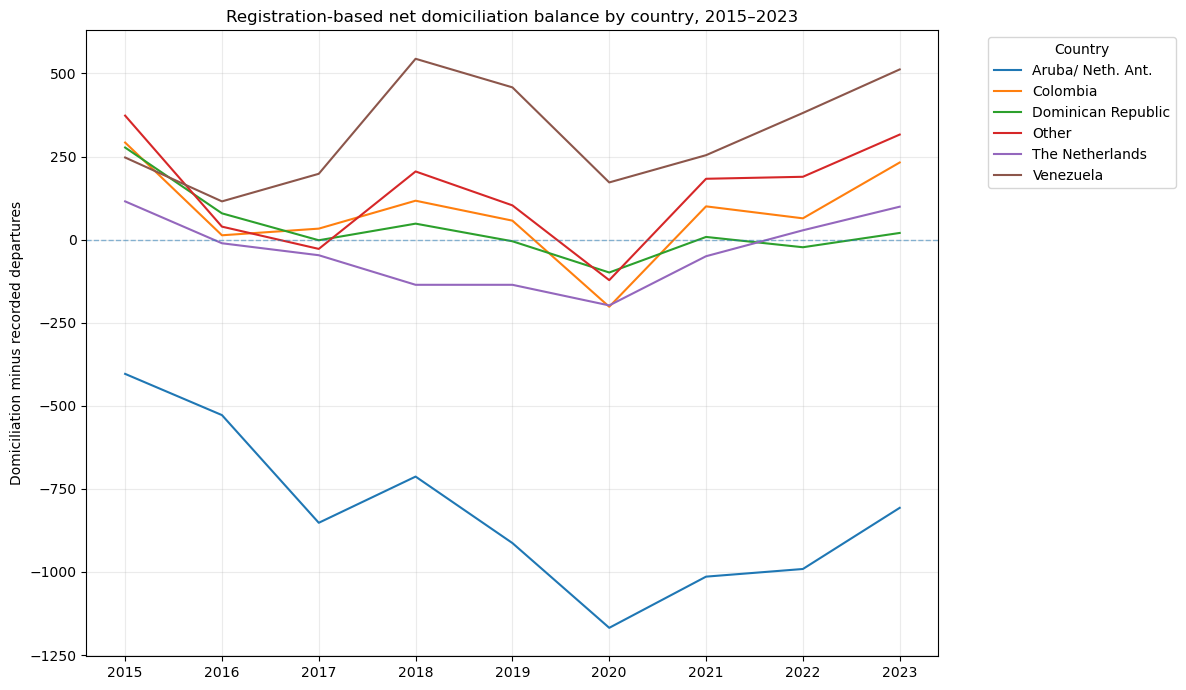

In [12]:
plt.figure(figsize=(12, 7))
plt.grid(alpha=0.25)

for country in annual_country_flow["country"].unique():
    data = annual_country_flow[annual_country_flow["country"] == country]

    plt.plot(
    data["year"],
    data["net_domiciliation_balance"],
    label=country
    )

plt.axhline(0, linewidth=1, linestyle='--', alpha=0.5)

plt.title("Registration-based net domiciliation balance by country, 2015–2023")
plt.ylabel("Domiciliation minus recorded departures")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

plt.savefig(FIGURES / "registration-based_net_dom_bal_country.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Summary calculation of mean and median of domiciliation, departures and net balances

In [13]:
summary = (
    country_flow.groupby("country").agg(
        mean_domiciliation=("domiciliation", "mean"),
        median_dimiciliation=("domiciliation", "median"),
        mean_departures=("departures", "mean"),
        median_departures=("departures", "median"),
        mean_balance=("net_domiciliation_balance", "mean"),
        median_balance=("net_domiciliation_balance", "median"),).sort_values(
        "mean_balance",
        ascending=False))

### 6.1 Figure 2 - Yearly total registered domiciliation and departures

In [14]:
# Yearly total registrated domiciliations and departures

annual_total_flow = (
    total_flow.groupby("year", as_index=False).agg(
        total_domiciliation=("domiciliation", "sum"),
        total_departures=("departures", "sum"),
        total_net_domiciliation_balance=("net_domiciliation_balance", "sum")))

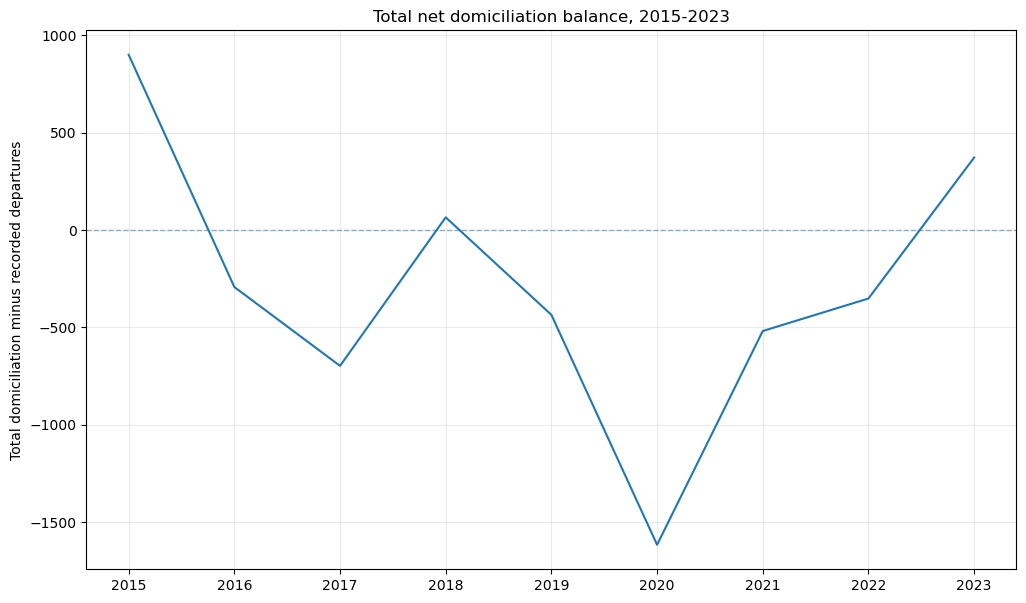

In [15]:
plt.figure(figsize=(12, 7))
plt.grid(alpha=0.25)

plt.plot(
    annual_total_flow["year"],
    annual_total_flow["total_net_domiciliation_balance"])

plt.axhline(0, linewidth=1, linestyle='--', alpha=0.5)

plt.title("Total net domiciliation balance, 2015-2023")
plt.ylabel("Total domiciliation minus recorded departures")

plt.savefig(FIGURES / "total_net_dom_balance.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
annual_total_flow_sex = (
    total_flow
    .groupby(["year", "sex"], as_index=False)
    .agg(
        total_domiciliation=("domiciliation", "sum"),
        total_departures=("departures", "sum"),
        total_net_domiciliation_balance=("net_domiciliation_balance", "sum")
    )
)

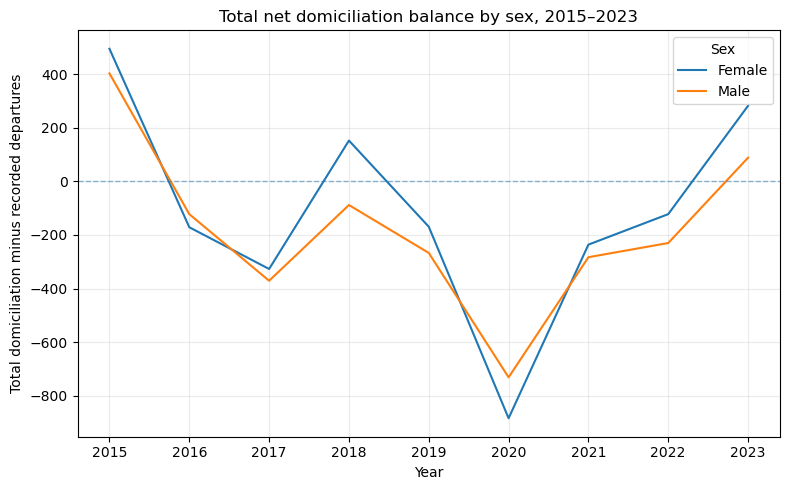

In [17]:
plt.figure(figsize=(8, 5))
plt.grid(alpha=0.25)

for sex in annual_total_flow_sex["sex"].unique():
    data = annual_total_flow_sex[annual_total_flow_sex["sex"] == sex]
    
    plt.plot(
        data["year"],
        data["total_net_domiciliation_balance"],
        label=sex
    )

plt.axhline(0, linewidth=1, linestyle='--', alpha=0.5)

plt.title("Total net domiciliation balance by sex, 2015–2023")
plt.xlabel("Year")
plt.ylabel("Total domiciliation minus recorded departures")
plt.legend(title="Sex")

plt.tight_layout()
plt.show()

## 7. Descriptive statistics

Here we use the describe function to calculate all the descriptive statistics of both the **domiciliation** and the **departures** data frames.

In [18]:
total_dom_df = dom_df[dom_df["country"].eq("Total Domociliation")].copy()
country_dom_df = dom_df[~dom_df["country"].eq("Total Domiciliation")].copy()

country_dom_df["domiciliation"].describe()

count     126.000000
mean      390.920635
std       425.570255
min        27.000000
25%       163.750000
50%       255.000000
75%       370.750000
max      1815.000000
Name: domiciliation, dtype: float64

In [19]:
total_dep_df = dep_df[dep_df["country"].eq("Total Departures")].copy()
country_dep_df = dep_df[~dep_df["country"].eq("Total Departures")].copy()

country_dep_df["departures"].describe()

count     126.000000
mean      431.841270
std       506.111883
min        26.000000
25%        79.500000
50%       205.500000
75%       724.000000
max      1849.000000
Name: departures, dtype: float64

**Summary statistics were calculated separately for total rows and country-level rows. Total rows were excluded from country-level descriptive statistics to avoid mixing aggregate values with subcategory values.**\
\
Country-level summaries show that departure values are not evenly distributed across origin categories. The category Aruba/ Neth. Ant. has substantially higher departure counts than all other groups, which raises the overall departure mean. For most other country categories, average domiciliation exceeds average departures.

| Variabele     | Count |   Mean |    Std | Min | Median | Max |
| ------------- | ----: | -----: | -----: | --: | -----: | --: |
| Domiciliation |   108 | 228.04 | 111.09 |  27 | 230.50 | 432 |
| Departures    |   108 | 251.91 | 258.14 |  26 | 162.00 | 933 |


In [20]:
country_dom_df.groupby("country")["domiciliation"].agg(
    count="count",
    min="min",
    median="median",
    mean="mean",
    max="max",
).sort_values("mean", ascending=False)

,count,min,median,mean,max
country,,,,,
Total,18,882,1366.5,1368.222222,1815
Aruba/ Neth. Ant.,18,295,382.0,378.555556,432
Other,18,135,256.0,266.277778,416
The Netherlands,18,186,256.0,257.722222,370
Venezuela,18,111,199.5,216.611111,381
Colombia,18,82,171.5,171.333333,290
Dominican Republic,18,27,69.0,77.722222,184


In [21]:
country_dep_df.groupby("country")["departures"].agg(
    count="count",
    min="min",
    median="median",
    mean="mean",
    max="max"
).sort_values("mean", ascending=False)

,count,min,median,mean,max
country,,,,,
Total,18,1298,1503.0,1511.444444,1849
Aruba/ Neth. Ant.,18,607,821.5,789.111111,933
The Netherlands,18,207,292.5,276.388889,352
Other,18,97,201.0,196.388889,275
Colombia,18,63,122.5,132.111111,253
Dominican Republic,18,26,51.0,60.888889,120
Venezuela,18,42,53.5,56.555556,85


## 8. Summary calculation table 2

In [22]:
summary_2 = (
    country_dom_df.groupby("country")["domiciliation"]
    .agg(mean_domiciliation="mean", median_domiciliation="median")
    .join(
        country_dep_df.groupby("country")["departures"]
        .agg(mean_departures="mean", median_departures="median")
    )
)

summary_2["mean_balance"] = (
    summary_2["mean_domiciliation"] - summary_2["mean_departures"]
)

summary_2.sort_values("mean_balance")

,mean_domiciliation,median_domiciliation,mean_departures,median_departures,mean_balance
country,,,,,
Aruba/ Neth. Ant.,378.555556,382.0,789.111111,821.5,-410.555556
Total,1368.222222,1366.5,1511.444444,1503.0,-143.222222
The Netherlands,257.722222,256.0,276.388889,292.5,-18.666667
Dominican Republic,77.722222,69.0,60.888889,51.0,16.833333
Colombia,171.333333,171.5,132.111111,122.5,39.222222
Other,266.277778,256.0,196.388889,201.0,69.888889
Venezuela,216.611111,199.5,56.555556,53.5,160.055556


### 8.1 Plot

### Comparison figure

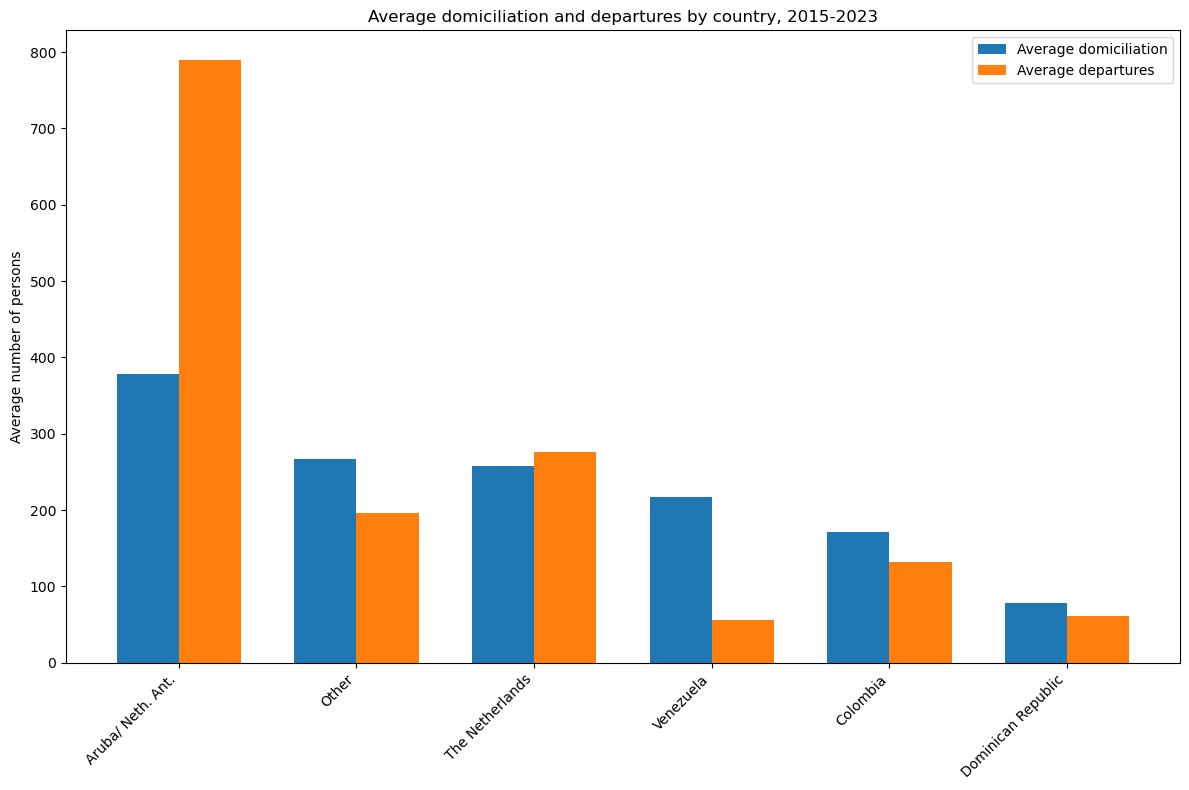

In [23]:
summary_2.index = summary_2.index.str.strip()
plot_df = summary_2[~summary_2.index.str.startswith("Total")].copy()

plot_df = plot_df.sort_values(by="mean_domiciliation", ascending=False)

x = np.arange(len(plot_df.index))
width = 0.35

plt.figure(figsize=(12,8))

plt.bar(x - width/2, plot_df["mean_domiciliation"], width, label="Average domiciliation")
plt.bar(x + width/2, plot_df["mean_departures"], width, label="Average departures")

plt.xticks(x, plot_df.index, rotation=45, ha="right")
plt.ylabel("Average number of persons")
plt.title("Average domiciliation and departures by country, 2015-2023")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES / "avg_dom_and_dep_by_country.png", dpi=300, bbox_inches="tight")
plt.show()

The figure shows average domiciliation and departures by country category across 2015–2023, excluding total rows. Aruba/ Neth. Ant. shows a structurally higher departure level, while Venezuela shows a consistently higher domiciliation level relative to departures.

Domiciliation alone only shows one side of Aruba’s registration dynamics. By comparing formal resident registrations with recorded departures, a more nuanced picture emerges: some origin categories show a consistently positive registration balance, while others show structurally higher departures. This distinction matters because population movement is not simply about arrival, but also about exit, registration, and administrative visibility.

---

In [24]:
print(flow.shape)
print(total_flow.shape)
print(country_flow.shape)

flow.isna().sum()

(126, 7)
(18, 7)
(108, 7)


country                             0
domiciliation                       0
year                                0
sex                                 0
departures                          0
net_domiciliation_balance           0
departure_to_domiciliation_ratio    0
dtype: int64